# Neural Network Classifier — XGB Feature Set

Trains a `ThreeLayerNN` (PyTorch) on the feature set selected upstream by the XGBoost
pipeline (`Input_lists/XGB_CLASSIFY_INPUT.txt`). Architecture and tuned hyper-parameters
mirror Model 1 to enable a like-for-like comparison across feature sets.

**Pipeline:** load → drop highly-correlated features → train / val / test split →
standardize → train (early-stop on val) → evaluate **once** on test → ROC / CM / loss / SHAP.


In [1]:
import sys
sys.path.append('..')  # I_Project root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix,
)

from Modules.models import ThreeLayerNN
from Modules.Utils import full_feature_data_preprocess

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)
print(f"Using device: {device}")


Using device: mps


## Data — load, restrict to XGB feature set, split, scale

In [2]:
DATA_PATH = '/Users/prometheus/Documents/Python/I_Project/Data/AppML_InitialProject_train.h5'
FEATURE_LIST_PATH = '/Users/prometheus/Documents/Python/I_Project/Input_lists/XGB_CLASSIFY_INPUT.txt'
TARGET = 'p_Truth_isElectron'

X_trainval, X_test, y_trainval, y_test = full_feature_data_preprocess(
    DATA_PATH, TARGET, test_size=0.2,
)

with open(FEATURE_LIST_PATH) as f:
    features = [line.strip() for line in f if line.strip()]

X_trainval = X_trainval[features]
X_test = X_test[features]

# Carve a validation set out of the training portion. The val set drives early
# stopping and the LR scheduler; the test set is touched once at the end.
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.2, random_state=SEED, stratify=y_trainval,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Features: {len(features)}")
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")


No missing values detected in the dataset.
Dropped 44 highly correlated features
Features: 15
Train: (115200, 15)  Val: (28800, 15)  Test: (36000, 15)


## Model, optimiser, dataloaders

In [3]:
params = {
    'lr': 0.0007511249842440639,
    'first_layer': 256,
    'second_layer': 32,
    'third_layer': 32,
    'batch_size': 256,
}

model = ThreeLayerNN(
    input_size=X_train.shape[1],
    first_layer_size=params['first_layer'],
    second_layer_size=params['second_layer'],
    third_layer_size=params['third_layer'],
).to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=params['lr'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y.values, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, params['batch_size'], shuffle=True)
val_loader = make_loader(X_val, y_val, params['batch_size'], shuffle=False)


## Training — early stopping on validation loss

In [4]:
CHECKPOINT = 'NN_top15_XGB.pth'
EPOCHS = 1000
PATIENCE = 20

def run_epoch(loader, train):
    model.train(train)
    total_loss = 0.0
    grad_ctx = torch.enable_grad() if train else torch.no_grad()
    with grad_ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).squeeze()
            loss = criterion(preds, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = run_epoch(train_loader, train=True)
    va_loss = run_epoch(val_loader, train=False)
    scheduler.step(va_loss)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    print(f"Epoch {epoch:>4}/{EPOCHS}  Train: {tr_loss:.4f}  Val: {va_loss:.4f}")

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})")
            break

model.load_state_dict(torch.load(CHECKPOINT, weights_only=True))


Epoch    1/1000  Train: 0.1807  Val: 0.1319
Epoch    2/1000  Train: 0.1254  Val: 0.1260
Epoch    3/1000  Train: 0.1196  Val: 0.1213
Epoch    4/1000  Train: 0.1152  Val: 0.1196
Epoch    5/1000  Train: 0.1118  Val: 0.1141
Epoch    6/1000  Train: 0.1086  Val: 0.1118
Epoch    7/1000  Train: 0.1065  Val: 0.1111
Epoch    8/1000  Train: 0.1044  Val: 0.1083
Epoch    9/1000  Train: 0.1027  Val: 0.1094
Epoch   10/1000  Train: 0.1013  Val: 0.1084
Epoch   11/1000  Train: 0.0998  Val: 0.1095
Epoch   12/1000  Train: 0.0994  Val: 0.1062
Epoch   13/1000  Train: 0.0982  Val: 0.1063
Epoch   14/1000  Train: 0.0975  Val: 0.1077
Epoch   15/1000  Train: 0.0967  Val: 0.1044
Epoch   16/1000  Train: 0.0964  Val: 0.1050
Epoch   17/1000  Train: 0.0959  Val: 0.1052
Epoch   18/1000  Train: 0.0950  Val: 0.1051
Epoch   19/1000  Train: 0.0947  Val: 0.1038
Epoch   20/1000  Train: 0.0937  Val: 0.1036
Epoch   21/1000  Train: 0.0944  Val: 0.1043
Epoch   22/1000  Train: 0.0936  Val: 0.1052
Epoch   23/1000  Train: 0.0930  

<All keys matched successfully>

## Test-set evaluation (single, final pass)

In [5]:
model.eval()
with torch.no_grad():
    y_proba = model(
        torch.tensor(X_test, dtype=torch.float32).to(device)
    ).squeeze().cpu().numpy()

y_pred = (y_proba > 0.5).astype(int)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")


Accuracy:  0.9622
Precision: 0.9282
Recall:    0.8864
F1:        0.9068


## Diagnostics — ROC, confusion matrix, training curves

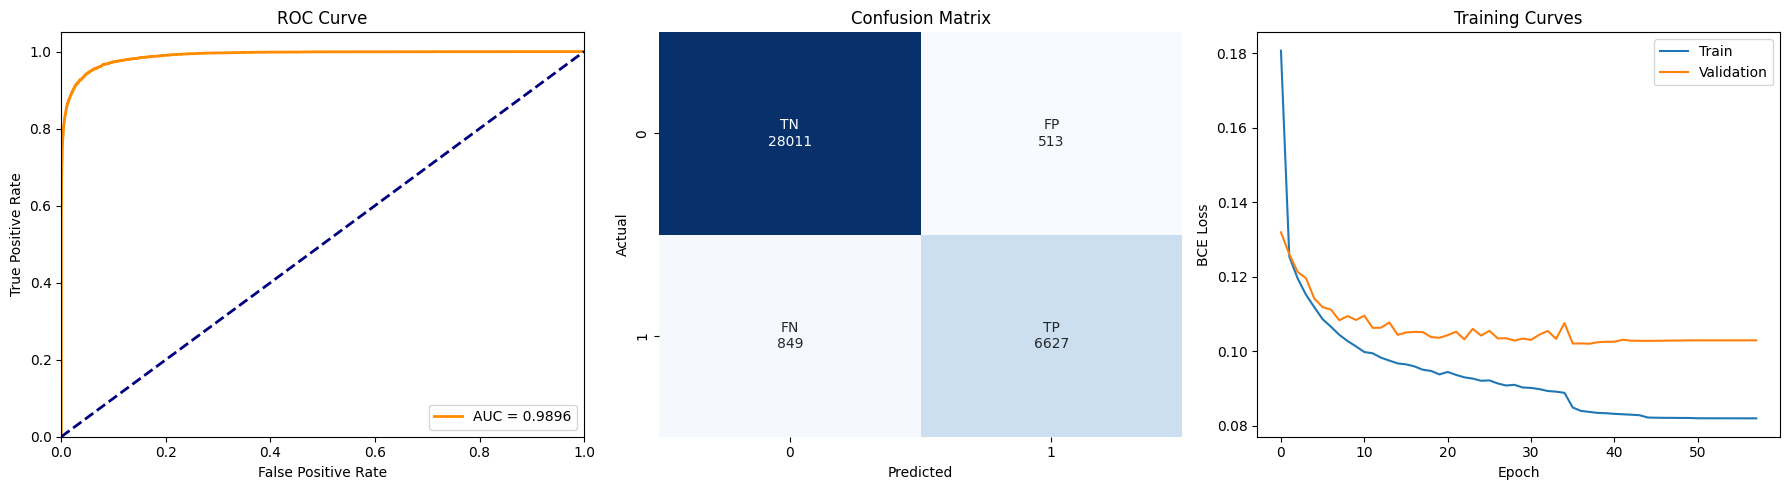

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

cm_labels = np.array([['TN', 'FP'], ['FN', 'TP']])
cm_annot = np.array([[f"{l}\n{v}" for l, v in zip(rl, rv)]
                     for rl, rv in zip(cm_labels, cm)])
sns.heatmap(cm, annot=cm_annot, fmt='', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')

axes[2].plot(train_losses, label='Train')
axes[2].plot(val_losses, label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BCE Loss')
axes[2].set_title('Training Curves')
axes[2].legend()

plt.tight_layout()
plt.show()


## Feature importance — SHAP

Run on **CPU** because MPS support in SHAP is incomplete and unreliable. We use `GradientExplainer` rather than `DeepExplainer` because the latter's DeepLIFT rules are unstable on saturating sigmoid outputs (additivity check fails). `GradientExplainer` uses *expected gradients* and handles arbitrary PyTorch graphs cleanly. A small random sample is used as the background distribution and to explain predictions for tractable runtime.

/var/folders/b2/8bddj55101b95xgghvl2vmrh0000gn/T/ipykernel_36885/159369119.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test[explain_idx], feature_names=features)


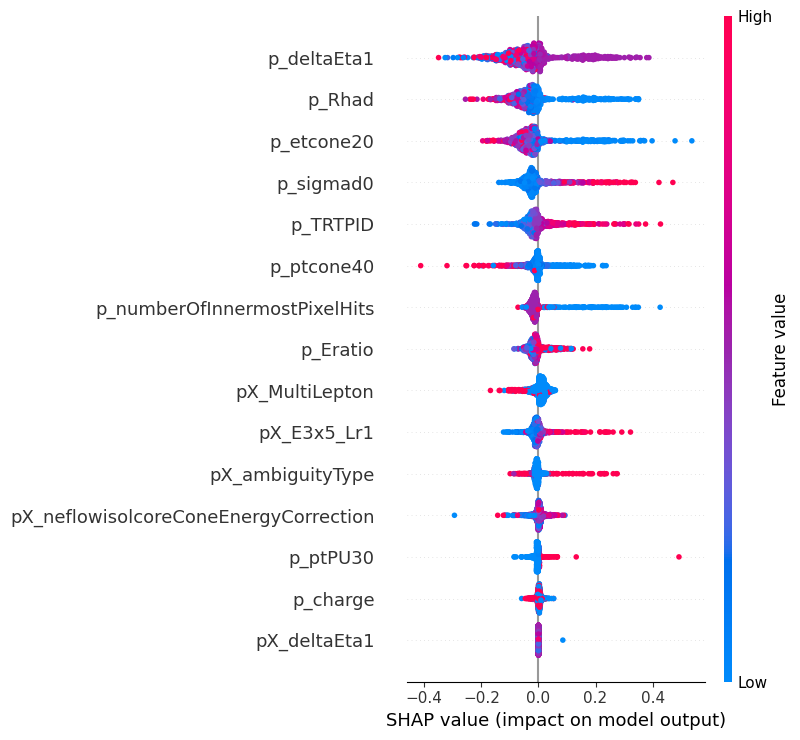

In [7]:
import shap

model_cpu = model.to('cpu').eval()

rng = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_train), size=min(200, len(X_train)), replace=False)
explain_idx = rng.choice(len(X_test), size=min(1000, len(X_test)), replace=False)

background = torch.tensor(X_train[bg_idx], dtype=torch.float32)
X_explain = torch.tensor(X_test[explain_idx], dtype=torch.float32)

explainer = shap.GradientExplainer(model_cpu, background)
shap_values = explainer.shap_values(X_explain)

# GradientExplainer returns either an array or a list (per output). Normalise
# to (n_samples, n_features).
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.asarray(shap_values).squeeze()

shap.summary_plot(shap_values, features=X_test[explain_idx], feature_names=features)
